In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [5]:
df = sns.load_dataset('exercise')
df.head()

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest


In [6]:
df.shape

(90, 6)

In [7]:
df.describe()

,Unnamed: 0,id,pulse
count,90.000000,90.000000,90.000000
mean,44.500000,15.500000,99.700000
std,26.124701,8.703932,14.858471
min,0.000000,1.000000,80.000000
25%,22.250000,8.000000,90.250000
50%,44.500000,15.500000,96.000000
75%,66.750000,23.000000,103.000000
max,89.000000,30.000000,150.000000


In [8]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,id,diet,pulse,time,kind
0,1,low fat,85,1 min,rest
1,1,low fat,85,15 min,rest
2,1,low fat,88,30 min,rest
3,2,low fat,90,1 min,rest
4,2,low fat,92,15 min,rest


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Copy dataframe aur 'id' drop karein (kyunki id feature nahi hai)
data = df.drop(columns=['id']).copy()

# 2. Categorical columns ko numeric mein encode karein
le = LabelEncoder()
data['diet'] = le.fit_transform(data['diet'])
data['time'] = le.fit_transform(data['time'])

# 3. Features (X) aur Target (y) alag karein
X = data[['diet', 'pulse', 'time']]
y = data['kind']

# 4. Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model train karein
model = GaussianNB()
model.fit(X_train, y_train)

# 6. Prediction aur Evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

        rest       0.83      0.62      0.71         8
     running       0.75      0.75      0.75         4
     walking       0.50      0.67      0.57         6

    accuracy                           0.67        18
   macro avg       0.69      0.68      0.68        18
weighted avg       0.70      0.67      0.67        18



In [10]:
edf = sns.load_dataset('iris')
edf.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
from sklearn.preprocessing import StandardScaler

# Agar 'species' abhi bacha hai toh drop karein, nahi toh ignore ho jaye
if 'species' in edf.columns:
    edf = edf.drop(columns=['species'])

scaler = StandardScaler()
# Scaled data ko wapas DataFrame bana lein taaki .head() kaam kare
edf_scaled = pd.DataFrame(scaler.fit_transform(edf), columns=edf.columns)

edf_scaled.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
edf.shape

(150, 4)

In [13]:
x = pca.fit_transform(edf_scaled)
x[:3]

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802]])

In [14]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

In [15]:
round(0.72962445 + 0.22850762,2)

0.96

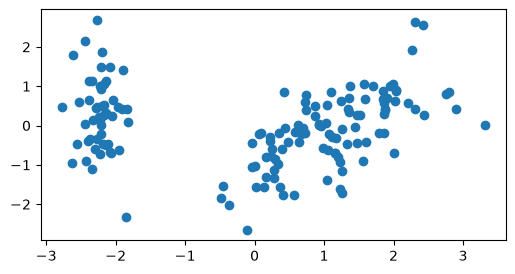

In [16]:
plt.figure(figsize=(6,3))
plt.scatter(x[:,0],x[:,1])
plt.show()